# RT-DETR-L Training

## Config and Paths

In [1]:
import os

DATASET_YAML = '/home/achin/COS40007-Group/dataset/dataset.yaml'
WEIGHTS_PATH = '/home/achin/COS40007-Group/rtdetr-l.pt'
PROJECT_DIR  = '/home/achin/COS40007-Group/runs/defect_detection'
DATASET_ROOT = '/home/achin/COS40007-Group/dataset'

RUN = 'rtdetr_l_v3_frozen'
CLASS_NAMES = ['crack', 'pothole', 'wall_peeling']
NC = 3
SPLITS = ['train', 'val', 'test']

IMAGE_DIRS = {s: os.path.join(DATASET_ROOT, s, 'images') for s in SPLITS}
LABEL_DIRS = {s: os.path.join(DATASET_ROOT, s, 'labels') for s in SPLITS}

print("Paths configured:")
for s in SPLITS:
    n_imgs = len([f for f in os.listdir(IMAGE_DIRS[s]) if f.endswith('.jpg')])
    print(f"  {s}: {n_imgs} images @ {IMAGE_DIRS[s]}")

Paths configured:
  train: 420 images @ /home/achin/COS40007-Group/dataset/train/images
  val: 90 images @ /home/achin/COS40007-Group/dataset/val/images
  test: 90 images @ /home/achin/COS40007-Group/dataset/test/images


## Dataset Exploratory Data Analysis


TRAIN: 420 images
  crack: 185 annotations
  pothole: 273 annotations
  wall_peeling: 222 annotations

VAL: 90 images
  crack: 42 annotations
  pothole: 51 annotations
  wall_peeling: 42 annotations

TEST: 90 images
  crack: 34 annotations
  pothole: 74 annotations
  wall_peeling: 35 annotations

Sample filenames (train):
  wall_peeling-093.jpg
  pothole-167.jpg
  crack-166.jpg
  pothole-092.jpg
  crack-042.jpg
  crack-093.jpg
  wall_peeling-166.jpg
  pothole-095.jpg
  wall_peeling-039.jpg


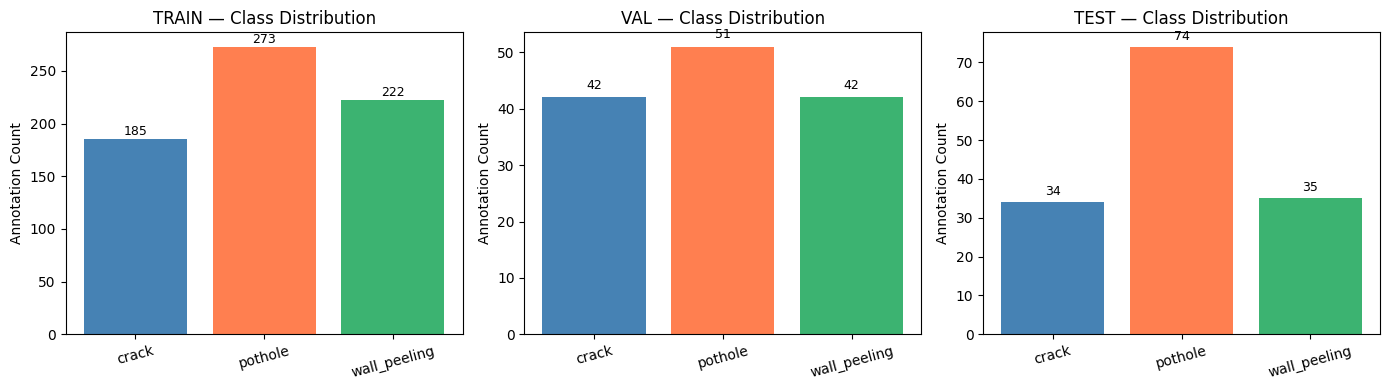

In [2]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

def count_labels(split):
    label_dir = Path(LABEL_DIRS[split])
    class_counts = Counter()
    for txt in label_dir.glob('*.txt'):
        for line in txt.read_text().strip().splitlines():
            if line.strip():
                cls = int(line.split()[0])
                class_counts[cls] += 1
    return class_counts

for split in SPLITS:
    counts = count_labels(split)
    total_images = len(list(Path(IMAGE_DIRS[split]).glob('*.jpg')))
    print(f"\n{split.upper()}: {total_images} images")
    for cls_id in sorted(counts):
        print(f"  {CLASS_NAMES[cls_id]}: {counts[cls_id]} annotations")

print("\nSample filenames (train):")
samples = list(Path(IMAGE_DIRS['train']).glob('*.jpg'))[:9]
for f in samples:
    print(f"  {f.name}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, split in zip(axes, SPLITS):
    counts = count_labels(split)
    names  = [CLASS_NAMES[i] for i in sorted(counts)]
    values = [counts[i] for i in sorted(counts)]
    bars = ax.bar(names, values, color=['steelblue', 'coral', 'mediumseagreen'])
    ax.set_title(f'{split.upper()} — Class Distribution')
    ax.set_ylabel('Annotation Count')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

## Visualise Sample Annotations

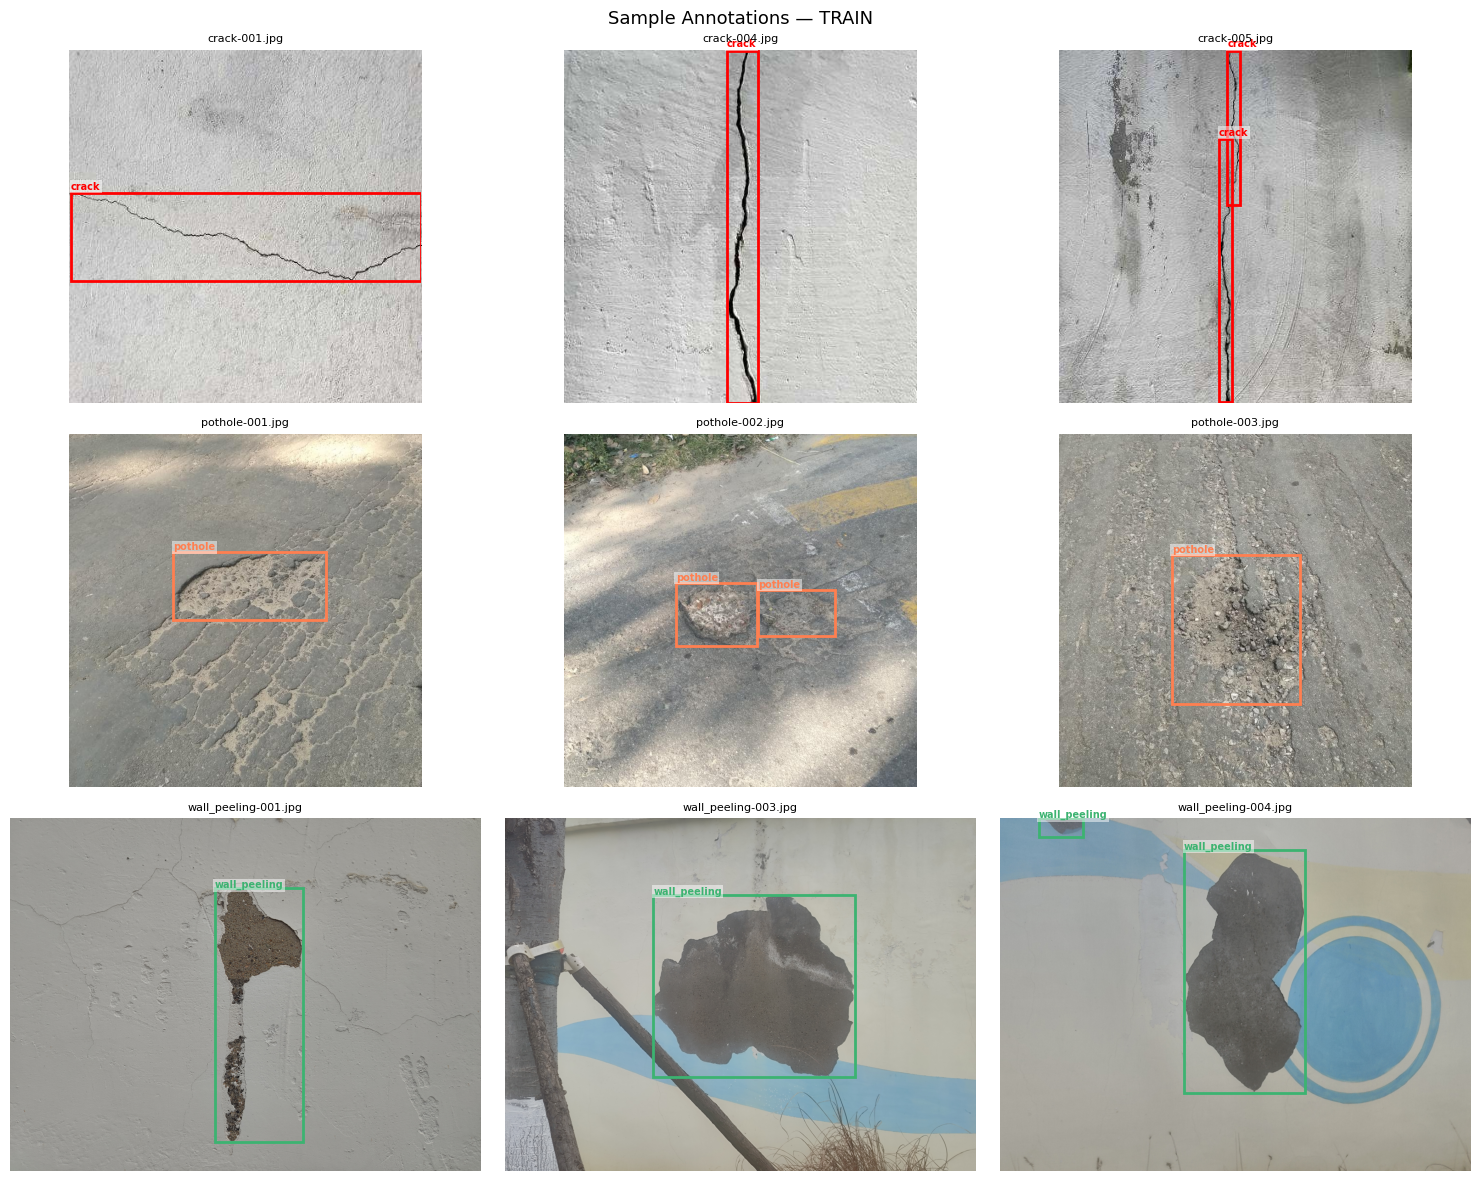

In [3]:
import matplotlib.patches as patches
from PIL import Image

def visualize_samples_by_class(split, n_per_class=3):
    img_dir = Path(IMAGE_DIRS[split])
    lbl_dir = Path(LABEL_DIRS[split])
    COLORS  = ['red', 'coral', 'mediumseagreen']

    fig, axes = plt.subplots(NC, n_per_class, figsize=(5 * n_per_class, 4 * NC))

    for row, cls_name in enumerate(CLASS_NAMES):
        cls_imgs = sorted(img_dir.glob(f'{cls_name}-*.jpg'))[:n_per_class]  # hyphen fixed

        for col in range(n_per_class):
            ax = axes[row][col]
            ax.axis('off')

            if col >= len(cls_imgs):
                ax.set_title(f'{cls_name} — no sample', fontsize=9)
                continue

            img_path = cls_imgs[col]
            img = Image.open(img_path).convert('RGB')
            w, h = img.size
            ax.imshow(img)
            ax.set_title(f'{img_path.name}', fontsize=8)

            lbl_path = lbl_dir / (img_path.stem + '.txt')
            if lbl_path.exists():
                for line in lbl_path.read_text().strip().splitlines():
                    parts = line.split()
                    if not parts:
                        continue
                    c, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    rect = patches.Rectangle(
                        (x1, y1), bw*w, bh*h,
                        linewidth=2, edgecolor=COLORS[c % len(COLORS)], facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 4, CLASS_NAMES[c], color=COLORS[c % len(COLORS)],
                            fontsize=7, fontweight='bold',
                            bbox=dict(facecolor='white', alpha=0.5, pad=1, edgecolor='none'))

    plt.suptitle(f'Sample Annotations — {split.upper()}', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, f'sample_annotations_{split}.png'), dpi=150)
    plt.show()

visualize_samples_by_class('train', n_per_class=3)

## Training

In [4]:
from ultralytics import RTDETR

os.makedirs(PROJECT_DIR, exist_ok=True)

model = RTDETR(WEIGHTS_PATH)

results = model.train(
    data=DATASET_YAML,
    epochs=300,
    freeze=21,
    lr0=5e-4,
    lrf=0.01,
    warmup_epochs=5,
    optimizer='AdamW',
    weight_decay=1e-4,
    patience=50,
    workers=4,
    mosaic=1.0,
    copy_paste=0.3,
    hsv_v=0.4,
    hsv_s=0.7,
    fliplr=0.5,
    scale=0.5,
    degrees=10.0,
    amp=False,
    device=0,
    project=PROJECT_DIR,
    name=RUN,
    exist_ok=True,
)

print("Training complete.")
print(f"Best weights saved to: {PROJECT_DIR}/{RUN}/weights/best.pt")

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/achin/COS40007-Group/dataset/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=21, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/achin/COS40007-Group/rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_l_v3_frozen, nbs=64, nms=False, opset=N

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


optimizer: AdamW(lr=0.0005, momentum=0.937) with parameter groups 143 weight(decay=0.0), 206 weight(decay=0.0001), 226 bias(decay=0.0)
Plotting labels to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v3_frozen/labels.jpg... 
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v3_frozen
Starting training for 300 epochs...

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/300      22.4G      1.942      1.076      1.567          4       1280: 100% ━━━━━━━━━━━━ 27/27 1.4it/s 19.2s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.3it/s 0.6s0.4s
                   all         90        135    3.7e-05     0.0238   0.000122   1.28e-05

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/300      22.4G      1.729     0.6073      1.416         16       1280: 0% ──────────── 0/27  0.6s

...

    152/300      22.8G     0.3175     0.3837     0.1452          4       1280: 100% ━━━━━━━━━━━━ 27/27 1.8it/s 15.4s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.5it/s 0.6s0.4s
                   all         90        135      0.814      0.581      0.611      0.354

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
    153/300      22.8G     0.3063     0.4623      0.111         16       1280: 0% ──────────── 0/27  0.6s

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    153/300      22.8G     0.3097     0.3991     0.1307          4       1280: 100% ━━━━━━━━━━━━ 27/27 1.8it/s 15.3s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.5it/s 0.5s0.4s
                   all         90        135       0.77      0.578      0.624      0.338

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
    154/300      22.8G     0.2573     0.4082     0.1091         16       1280: 0% ──────────── 0/27  0.6s

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    154/300      22.8G     0.3043     0.3945     0.1342          4       1280: 100% ━━━━━━━━━━━━ 27/27 1.8it/s 15.3s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.5it/s 0.5s0.4s
                   all         90        135      0.778      0.605      0.639      0.345
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 104, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

154 epochs completed in 0.719 hours.
Optimizer stripped from /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v3_frozen/weights/last.pt, 66.2MB
Optimizer stripped from /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v3_frozen/weights/best.pt, 66.2MB

Validating /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v3_frozen/weights/best.pt...
Ultralytics 8

## Validation on Val Set

In [5]:
best_weights = os.path.join(PROJECT_DIR, RUN, 'weights', 'best.pt')
trained_model = RTDETR(best_weights)

val_metrics = trained_model.val(
    data=DATASET_YAML,
    split='val',
    plots=True,
    save_json=True,
    project=PROJECT_DIR,
    name=f'{RUN}_val',
    exist_ok=True,
)

print("\n--- Val Metrics ---")
print(f"mAP@50:     {val_metrics.box.map50:.4f}")
print(f"mAP@50-95:  {val_metrics.box.map:.4f}")
print(f"Precision:  {val_metrics.box.mp:.4f}")
print(f"Recall:     {val_metrics.box.mr:.4f}")
print(f"\nPer-class AP@50:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {val_metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 553.6±454.6 MB/s, size: 43.5 KB)
val: Scanning /home/achin/COS40007-Group/dataset/val/labels.cache... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 18.0Mit/s 0.0s


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.7it/s 1.6s0.3s
                   all         90        135       0.75      0.645      0.667      0.368
                 crack         30         42      0.718      0.486      0.531      0.224
              potholes         30         51      0.759      0.686      0.703      0.389
          wall_peeling         30         42      0.772      0.762      0.766      0.492
Speed: 0.6ms preprocess, 8.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v3_frozen_val/predictions.json...
Results saved to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v3_frozen_val

--- Val Metrics ---
mAP@50:     0.6669
mAP@50-95:  0.3685
Precision:  0.7499
Recall:     0.6448

Per-class AP@50:
  crack: 0.5312
  pothole: 0.7031
  wall_peeling: 0.7664


## Evaluation on Test Set

In [6]:
test_metrics = trained_model.val(
    data=DATASET_YAML,
    split='test',
    plots=True,
    project=PROJECT_DIR,
    name=f'{RUN}_test',
    exist_ok=True,
)

print("\n--- Test Metrics ---")
print(f"mAP@50:     {test_metrics.box.map50:.4f}")
print(f"mAP@50-95:  {test_metrics.box.map:.4f}")
print(f"Precision:  {test_metrics.box.mp:.4f}")
print(f"Recall:     {test_metrics.box.mr:.4f}")
print(f"\nPer-class AP@50:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {test_metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.0 ms, read: 58.0±48.9 MB/s, size: 53.9 KB)
val: Scanning /home/achin/COS40007-Group/dataset/test/labels.cache... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 27.0Mit/s 0.0s


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 4.4it/s 1.4s0.2s
                   all         90        143      0.734      0.737      0.738      0.412
                 crack         30         34      0.694      0.734      0.739      0.306
              potholes         30         74      0.686       0.62      0.608      0.382
          wall_peeling         30         35      0.822      0.857      0.868      0.549
Speed: 0.6ms preprocess, 6.6ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v3_frozen_test

--- Test Metrics ---
mAP@50:     0.7385
mAP@50-95:  0.4125
Precision:  0.7342
Recall:     0.7370

Per-class AP@50:
  crack: 0.7389
  pothole: 0.6084
  wall_peeling: 0.8682


## Training Curves

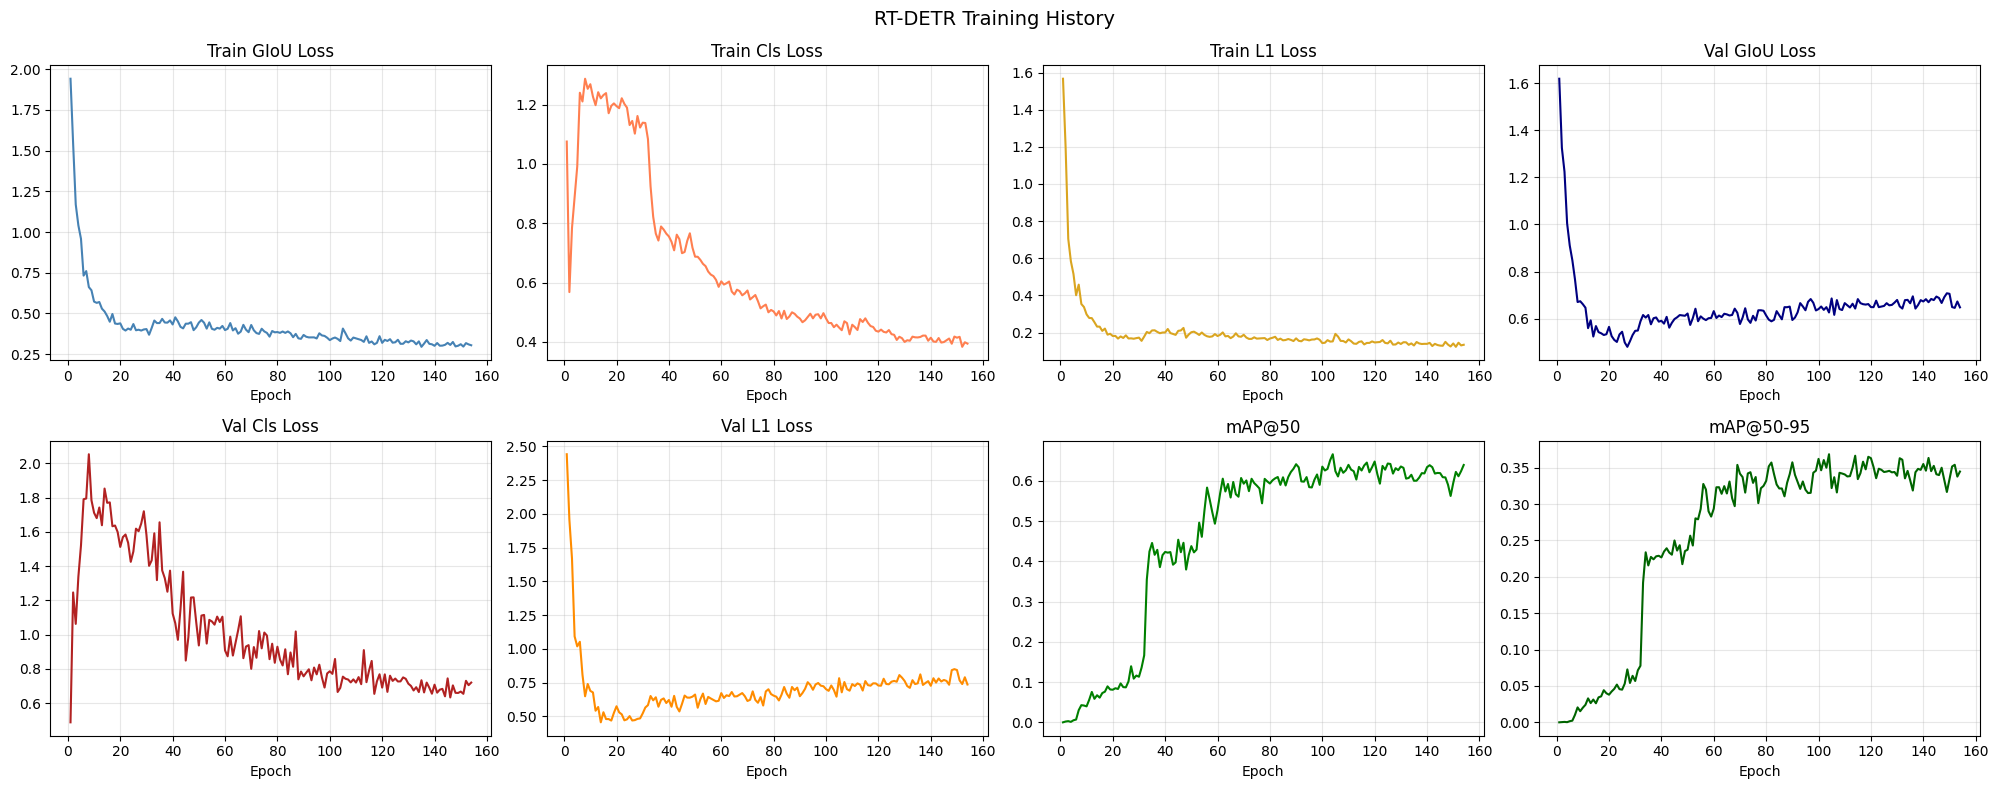

In [7]:
import pandas as pd
import matplotlib.image as mpimg

results_csv = os.path.join(PROJECT_DIR, RUN, 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

plots = [
    ('train/giou_loss',       'Train GIoU Loss',  'steelblue'),
    ('train/cls_loss',        'Train Cls Loss',   'coral'),
    ('train/l1_loss',         'Train L1 Loss',    'goldenrod'),
    ('val/giou_loss',         'Val GIoU Loss',    'navy'),
    ('val/cls_loss',          'Val Cls Loss',     'firebrick'),
    ('val/l1_loss',           'Val L1 Loss',      'darkorange'),
    ('metrics/mAP50(B)',      'mAP@50',           'green'),
    ('metrics/mAP50-95(B)',   'mAP@50-95',        'darkgreen'),
    ('metrics/precision(B)',  'Precision',        'purple'),
    ('metrics/recall(B)',     'Recall',           'orange'),
    ('lr/pg0',                'LR (backbone)',    'gray'),
    ('lr/pg1',                'LR (weights)',     'darkgray'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, (col, title, color) in zip(axes.flatten(), plots):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=1.5)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} (not found)')
        ax.axis('off')

plt.suptitle('RT-DETR Training History', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## Inference and Visualisation on Test Images


image 1/90 /home/achin/COS40007-Group/dataset/test/images/crack-002.jpg: 640x640 5 cracks, 19.1ms
image 2/90 /home/achin/COS40007-Group/dataset/test/images/crack-008.jpg: 640x640 12 cracks, 19.6ms
image 3/90 /home/achin/COS40007-Group/dataset/test/images/crack-009.jpg: 640x640 1 crack, 1 wall_peeling, 19.3ms
image 4/90 /home/achin/COS40007-Group/dataset/test/images/crack-014.jpg: 640x640 8 cracks, 19.1ms
image 5/90 /home/achin/COS40007-Group/dataset/test/images/crack-018.jpg: 640x640 7 cracks, 19.0ms
image 6/90 /home/achin/COS40007-Group/dataset/test/images/crack-021.jpg: 640x640 6 cracks, 19.1ms
image 7/90 /home/achin/COS40007-Group/dataset/test/images/crack-027.jpg: 640x640 2 cracks, 1 potholes, 19.0ms
image 8/90 /home/achin/COS40007-Group/dataset/test/images/crack-044.jpg: 640x640 1 crack, 1 potholes, 19.0ms
image 9/90 /home/achin/COS40007-Group/dataset/test/images/crack-049.jpg: 640x640 2 cracks, 19.2ms
image 10/90 /home/achin/COS40007-Group/dataset/test/images/crack-055.jpg: 640x

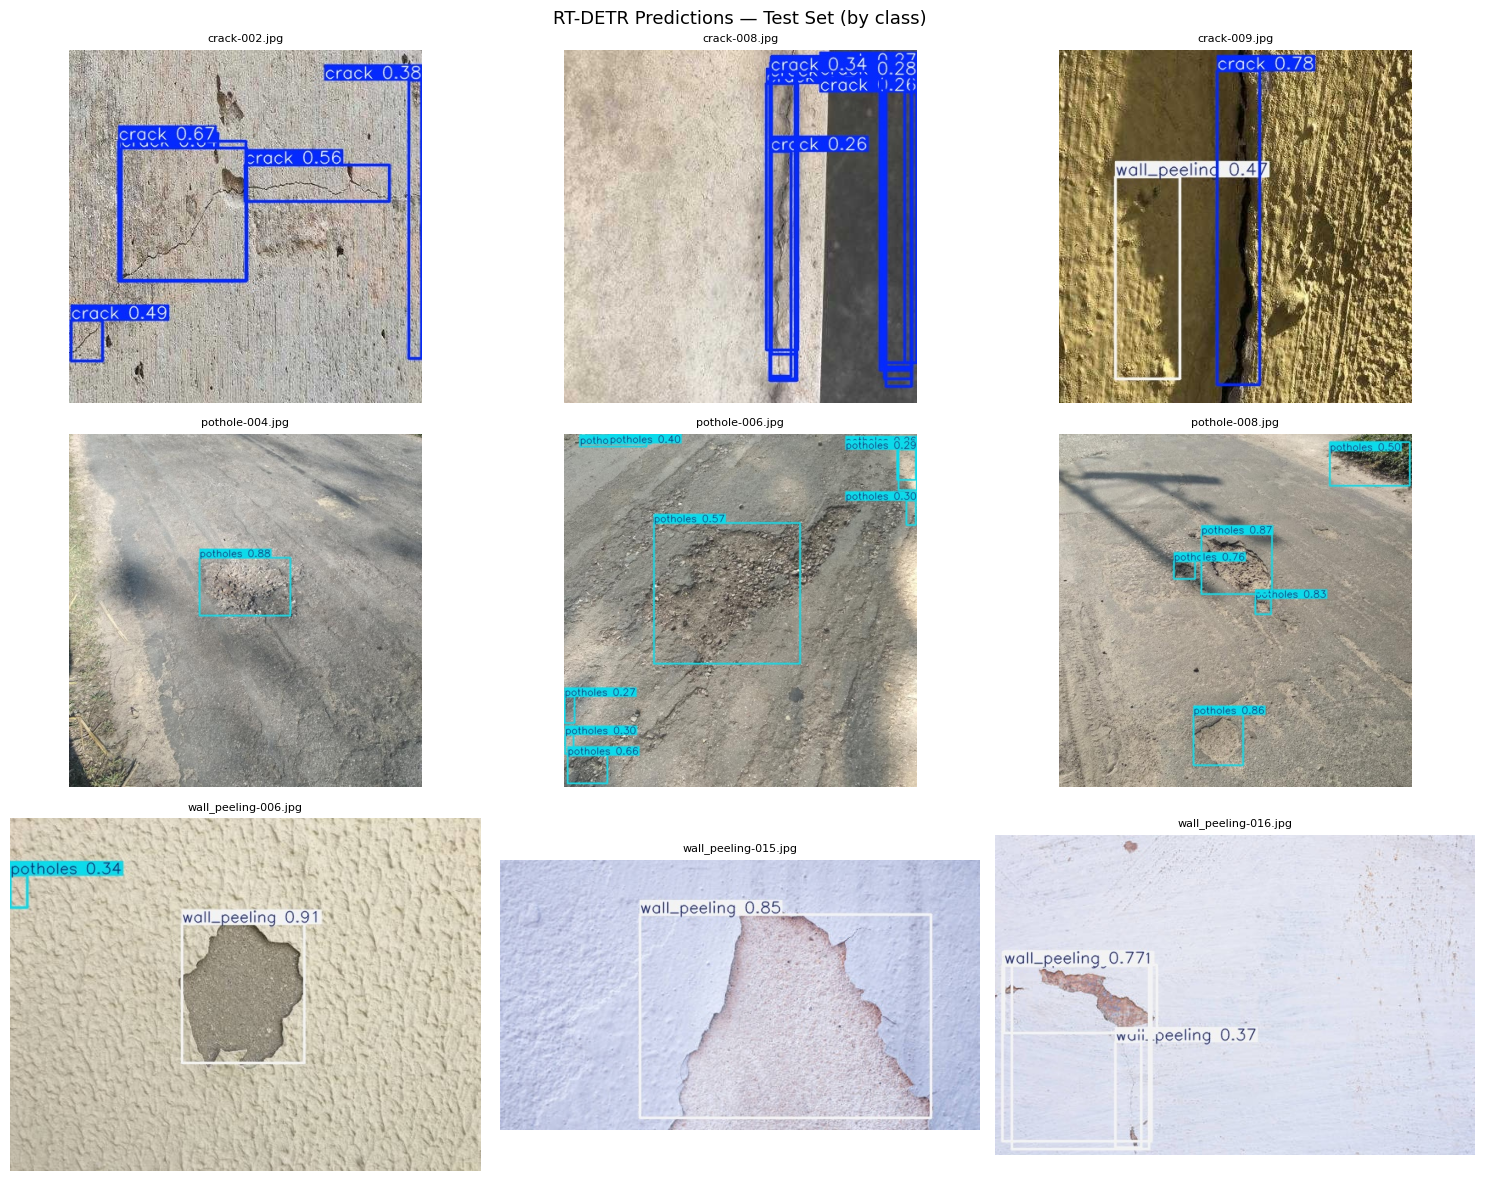

In [8]:
trained_model.predict(
    source=IMAGE_DIRS['test'],
    conf=0.25,
    iou=0.5,
    save=True,
    project=PROJECT_DIR,
    name=f'{RUN}_predictions',
    exist_ok=True,
)

pred_dir = Path(PROJECT_DIR) / f'{RUN}_predictions'

fig, axes = plt.subplots(NC, 3, figsize=(15, 4 * NC))
for row, cls_name in enumerate(CLASS_NAMES):
    cls_preds = sorted(pred_dir.glob(f'{cls_name}-*.jpg'))[:3]
    for col in range(3):
        ax = axes[row][col]
        ax.axis('off')
        if col < len(cls_preds):
            ax.imshow(mpimg.imread(cls_preds[col]))
            ax.set_title(cls_preds[col].name, fontsize=8)
        else:
            ax.set_title(f'{cls_name} — no prediction saved', fontsize=8)

plt.suptitle('RT-DETR Predictions — Test Set (by class)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'prediction_samples.png'), dpi=150)
plt.show()

## Display Evaluation Plots

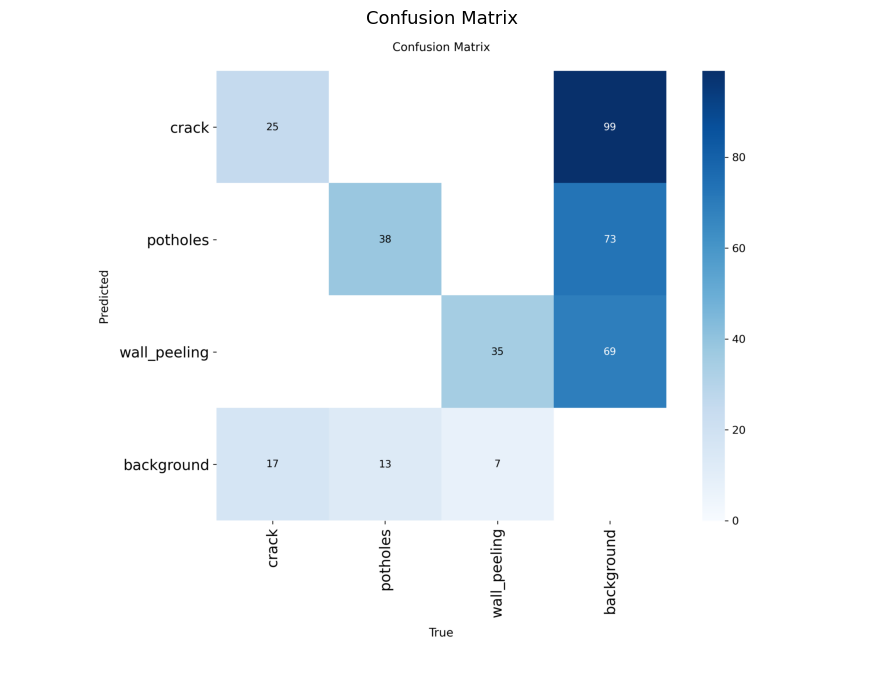

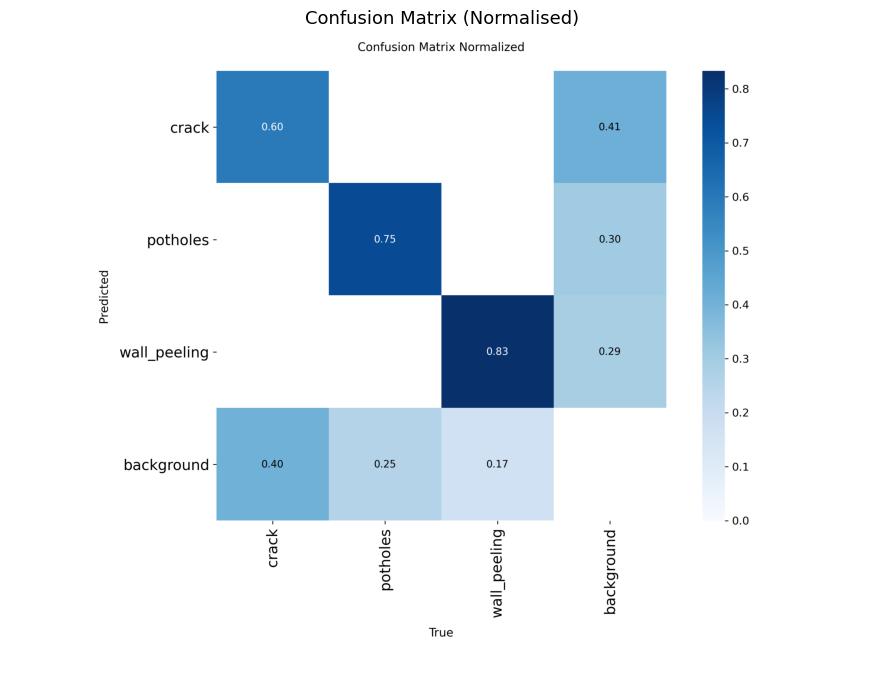

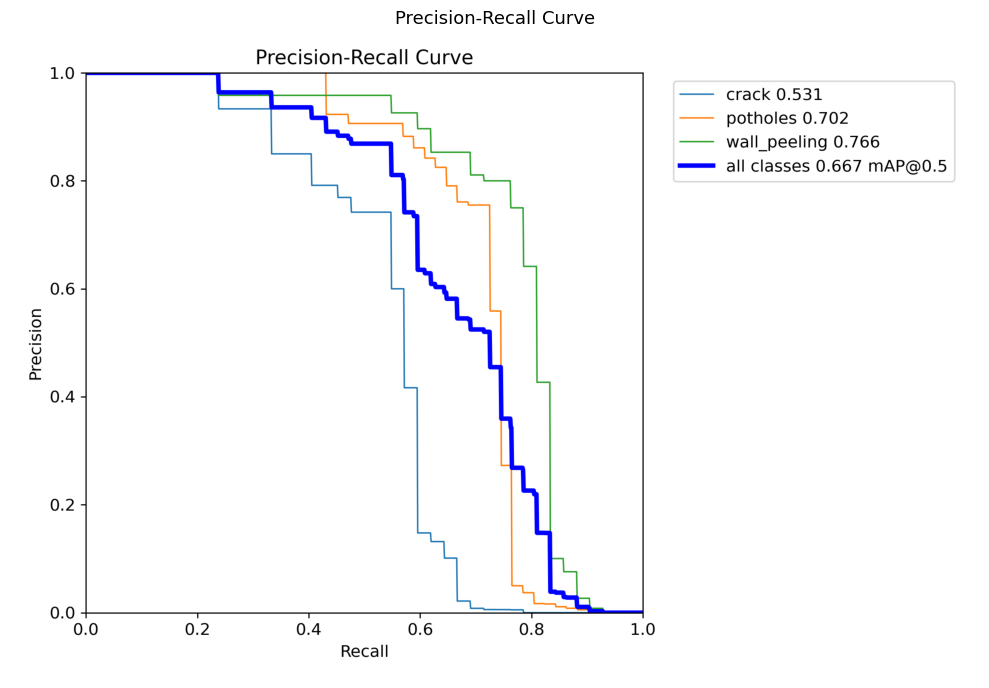

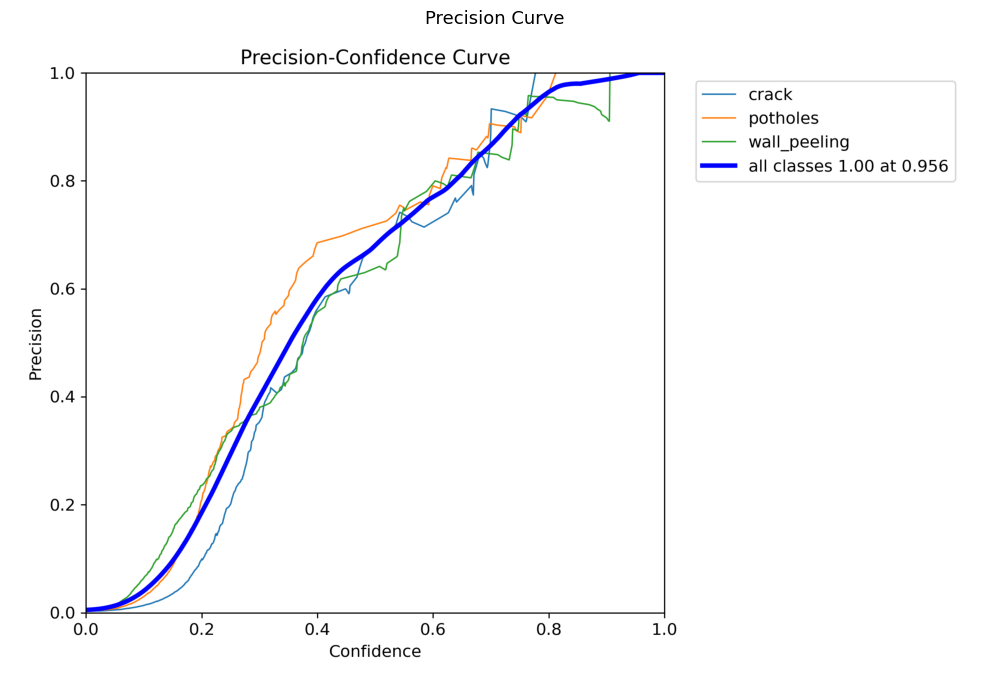

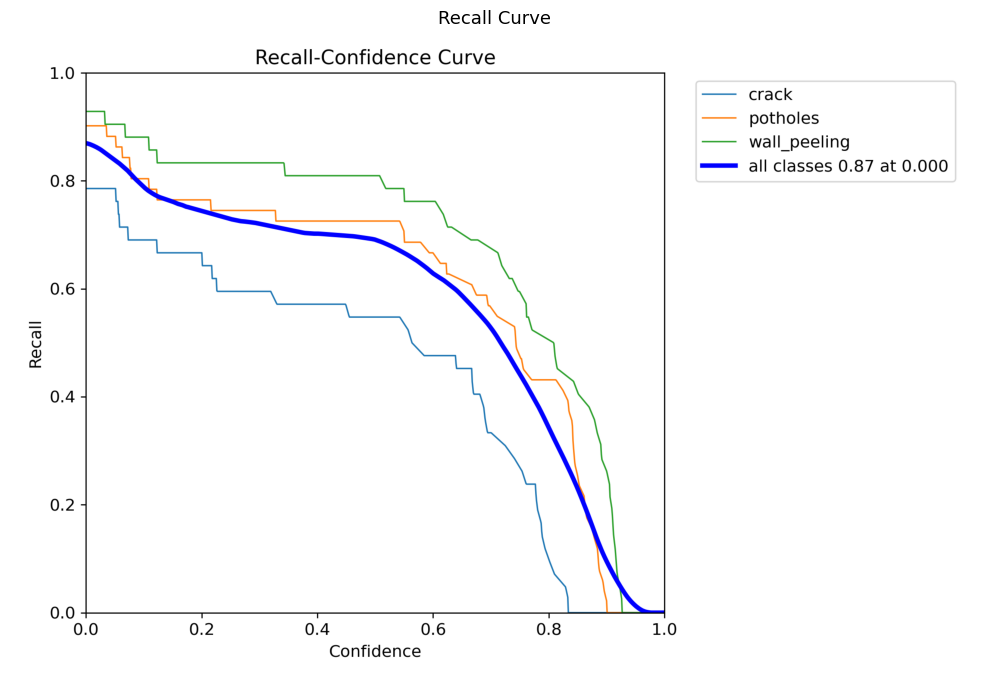

In [11]:
eval_plots = [
    ('confusion_matrix.png',            'Confusion Matrix'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalised)'),
    ('BoxPR_curve.png',                    'Precision-Recall Curve'),
    ('BoxP_curve.png',                     'Precision Curve'),
    ('BoxR_curve.png',                     'Recall Curve'),
]

run_dir = Path(PROJECT_DIR) / RUN

for filename, title in eval_plots:
    p = run_dir / filename
    if p.exists():
        plt.figure(figsize=(10, 7))
        plt.imshow(mpimg.imread(p))
        plt.title(title, fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Not yet generated: {filename}")

## Inference Speed Benchmark

In [10]:
import time

test_imgs = list(Path(IMAGE_DIRS['test']).glob('*.jpg'))[:50]

# Warmup
trained_model.predict(source=[str(test_imgs[0])], conf=0.25, verbose=False)

# Timed run
start = time.time()
trained_model.predict(source=[str(p) for p in test_imgs], conf=0.25, verbose=False)
elapsed = time.time() - start

fps = len(test_imgs) / elapsed
print(f"Images tested : {len(test_imgs)}")
print(f"Total time    : {elapsed:.2f}s")
print(f"FPS           : {fps:.1f}")
print(f"ms/image      : {1000/fps:.1f}")

Images tested : 50
Total time    : 0.51s
FPS           : 99.0
ms/image      : 10.1
